# Supplementary Analysis to better understand RQ2 Effects

Three models:

1. Plot of residuals from `E1 ~ Learning Session Count` grouped by control versus treatment
2. Plot of residuals from `E1 ~ Task Completion Session Count` grouped by control versus treatment
3. Plot of residuals from `E1 ~ Learning Session Count + Task Completion Session Count` grouped by control versus treatment

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TABLEAU_COLORS

import seaborn as sns
from scipy import stats
import json
import import_ipynb
from IPython.display import display
# from analysis_with_ai import invoke_openrouter_ai, INTERACTION_PROMPT_TEMPLATEv2, classify_interaction
# from helper_functions import independent_ttest
from helper_functions import linear_regression_analysis, linear_regression_assumption_checks

In [24]:
# Read in the final data set
dataset = pd.read_csv("../datasets/dps-thesis-dataset.csv")
dataset.columns

Index(['participant_number', 'survey_done', 'chatbot_done', 'chatbot_group',
       'first_year', 'gender', 'year_in_school_simplified',
       'first_prog_course', 'C1', 'C2', 'E1', 'Difference_C2_C1',
       'inconclusive_session_count', 'learning_session_count',
       'task_completion_session_count', 'total_session_count',
       'total_interaction_count', 'interaction_to_session_ratio',
       'control_treatment_asnumber', 'first_prog_course_asnumber',
       'gender_asnumber', 'year_in_school_simplified_asnumber'],
      dtype='object')

### Residuals Learning Session Count vs E1

Grouped by control versus treatment.


Fitting model with standard OLS...


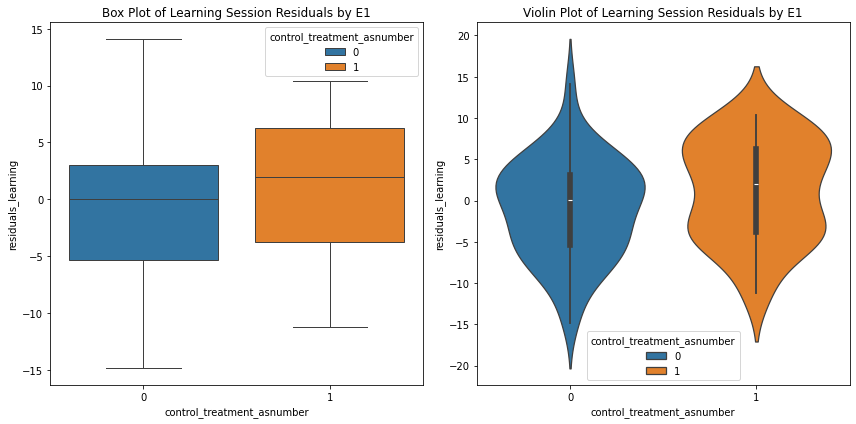

,count,mean,std,min,25%,50%,75%,max
control_treatment_asnumber,,,,,,,,
0,48.0,-0.971934,5.936866,-14.857902,-5.359269,0.010685,3.058939,14.107194
1,39.0,1.196226,6.096478,-11.214505,-3.764126,1.978515,6.300214,10.399457


In [25]:
ind_vars = ['learning_session_count']
dep_var = "E1"

model = linear_regression_analysis(dataset, ind_vars, dep_var, do_print=False, do_plot=False)

# Save residuals from the regression
residuals = model.resid
# Add residuals to dataset for plotting
dataset['residuals_learning'] = residuals
# show side by size box plots and violin plots of residuals by control vs treatment
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x='control_treatment_asnumber', y='residuals_learning', data=dataset, hue='control_treatment_asnumber', palette=list(TABLEAU_COLORS.values()))
plt.title('Box Plot of Learning Session Residuals by E1')
plt.subplot(1, 2, 2)
sns.violinplot(x='control_treatment_asnumber', y='residuals_learning', data=dataset, hue='control_treatment_asnumber', palette=list(TABLEAU_COLORS.values()))
plt.title('Violin Plot of Learning Session Residuals by E1')
plt.tight_layout()
plt.show()

# Descriptive statistics for residuals by control vs treatment
desc_stats = dataset.groupby('control_treatment_asnumber')['residuals_learning'].describe()
display(desc_stats)

### Residuals Task Completion Session Count vs E1

grouped by control versus treatment.



Fitting model with standard OLS...


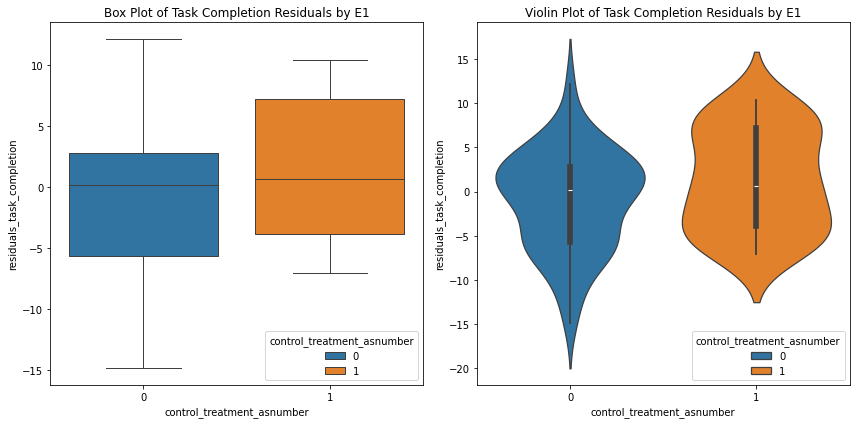

,count,mean,std,min,25%,50%,75%,max
control_treatment_asnumber,,,,,,,,
0,48.0,-1.007979,5.574422,-14.866952,-5.685634,0.133048,2.806124,12.133048
1,39.0,1.240589,5.662842,-7.072084,-3.883437,0.616563,7.186159,10.374806


In [26]:
ind_vars = ['task_completion_session_count']
dep_var = "E1"

model = linear_regression_analysis(dataset, ind_vars, dep_var, do_print=False, do_plot=False)

# Save residuals from the regression
residuals = model.resid
# Add residuals to dataset for plotting
dataset['residuals_task_completion'] = residuals
# show side by size box plots and violin plots of residuals by control vs treatment
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x='control_treatment_asnumber', y='residuals_task_completion', data=dataset, hue='control_treatment_asnumber', palette=list(TABLEAU_COLORS.values()))
plt.title('Box Plot of Task Completion Residuals by E1')
plt.subplot(1, 2, 2)
sns.violinplot(x='control_treatment_asnumber', y='residuals_task_completion', data=dataset, hue='control_treatment_asnumber', palette=list(TABLEAU_COLORS.values()))
plt.title('Violin Plot of Task Completion Residuals by E1')
plt.tight_layout()
plt.show()

# Descriptive statistics for residuals by control vs treatment
desc_stats = dataset.groupby('control_treatment_asnumber')['residuals_task_completion'].describe()
display(desc_stats)

## Residuals of both IV's on E1

broken down by control vs treatment


Fitting model with standard OLS...


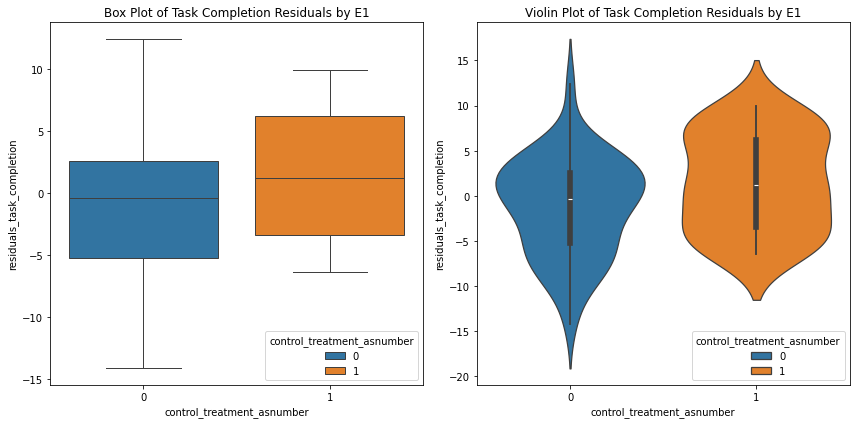

,count,mean,std,min,25%,50%,75%,max
control_treatment_asnumber,,,,,,,,
0,48.0,-1.199913,5.382352,-14.159344,-5.255646,-0.389248,2.563666,12.429346
1,39.0,1.476816,5.318900,-6.407109,-3.424441,1.223691,6.174777,9.928259


In [27]:
ind_vars = ['learning_session_count', 'task_completion_session_count']
dep_var = "E1"

model = linear_regression_analysis(dataset, ind_vars, dep_var, do_print=False, do_plot=False)

# Save residuals from the regression
residuals = model.resid
# Add residuals to dataset for plotting
dataset['residuals_task_completion'] = residuals
# show side by size box plots and violin plots of residuals by control vs treatment
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x='control_treatment_asnumber', y='residuals_task_completion', data=dataset, hue='control_treatment_asnumber', palette=list(TABLEAU_COLORS.values()))
plt.title('Box Plot of Task Completion Residuals by E1')
plt.subplot(1, 2, 2)
sns.violinplot(x='control_treatment_asnumber', y='residuals_task_completion', data=dataset, hue='control_treatment_asnumber', palette=list(TABLEAU_COLORS.values()))
plt.title('Violin Plot of Task Completion Residuals by E1')
plt.tight_layout()
plt.show()

# Descriptive statistics for residuals by control vs treatment
desc_stats = dataset.groupby('control_treatment_asnumber')['residuals_task_completion'].describe()
display(desc_stats)